In [1]:
import os
import random
import time
from datetime import date

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.nn import TransformerEncoder, TransformerEncoderLayer
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
DATA_PATH = "./data/2025-07-15_full_training_data_98066_samples.csv" # carbons log-uniform, others uniform
#datafile = "./data/2025-07-15_full_training_data_99518_easy_samples.csv" #log-uniform samples

In [3]:
# Set all random seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # For multi-GPU setups
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [4]:
if torch.backends.mps.is_available():
    device = torch.device('mps')  # Mac Metal Performance Shaders
    print(f"Training on device: {device} (Mac GPU)")
elif torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"Training on device: {device} (NVIDIA GPU)")
else:
    device = torch.device('cpu')
    print(f"Training on device: {device} (CPU)")

print(f"PyTorch version: {torch.__version__}")
if device.type == 'mps':
    print("Using Mac Metal Performance Shaders for GPU acceleration")

Training on device: cuda (NVIDIA GPU)
PyTorch version: 2.5.1+cu121


In [ ]:
class AttentionBlock(nn.Module):
    """Multi-head attention block for metabolic modeling"""
    def __init__(self, d_model=6, n_heads=2):
        super().__init__()

        assert d_model % n_heads==0, "model dimension must be divisible by number of heads"
        
        self.d_model = d_model
        
        self.layer_norm = nn.LayerNorm(d_model)
        
        self.k = d_model // n_heads

        self.W_k = nn.Linear(d_model, self.k, bias=False)
        self.W_q = nn.Linear(d_model, self.k, bias=False)
        self.W_v = nn.Linear(d_model, self.k, bias=False)
        self.W_o = nn.Linear(self.k, d_model, bias=False)
        # self.W_c = nn.Linear(vocab_size,vocab_size,bias=False)
        # Context projection (modified)
        #self.W_c = nn.Linear(1, self.k, bias=False)  # Projects context to head_dim

    def scaled_dot_product_attention(self, queries, keys, values):
        # b = batch, q = query pos, k = key pos, d = head dimension
        scores = torch.einsum('bqd, bkd -> bqk', queries, keys) / (self.d_model ** 0.5)
        #scores = torch.matmul(queries, keys.transpose(-2, -1)) / (self.d_model ** 0.5)
        attention_weights = torch.softmax(scores, dim=-1)
        attention_output = torch.einsum('bqk, bkd -> bqd', attention_weights, values)

        return attention_output, attention_weights

    def forward(self, x, c):
        norm_x = self.layer_norm(x)
        # modified_c = self.W_c(c.transpose(-2,-1)).transpose(-2,-1)
        modified_c = c
        #projected_c = self.W_c(c)
        
        Q = self.W_q(norm_x)
        K = self.W_k(norm_x)
        V = self.W_v(norm_x)

        attention_output, attention_weights = self.scaled_dot_product_attention(Q, K, V)

        #print(attention_weights.size(),modified_c.size())

        attended_c = torch.einsum('bqk, bkv -> bqv', attention_weights, modified_c)
        #attended_c = torch.matmul(attention_weights.transpose(-2, -1),  projected_c)  # (batch, seq_len, head_dim)
        
        #print(modified_c.size(),attended_c.size())

        output_x = self.W_o(attention_output) + x 
        output_c = attended_c + c

        # For c, keep the original dimension (1)
        #output_c = attended_c.mean(dim=-1, keepdim=True) + c

        return output_x, output_c

In [6]:
class MultiHeadAttentionBlock(nn.Module):
    """Multi-Head Attention layer for metabolic modeling"""
    def __init__(self, d_model=6, n_heads=2):
        super().__init__()

        self.attention_blocks = nn.ModuleList([AttentionBlock(d_model, n_heads) for _ in range(n_heads)])

    def forward(self,x,c):

        output_x = torch.zeros_like(x)
        output_c = torch.zeros_like(c)

        for attention_block in self.attention_blocks:
            o_x, o_c = attention_block(x,c)
            output_x += o_x
            output_c += o_c

        return output_x, output_c     

In [7]:
class FeedForwardBlock(nn.Module):

    def __init__(self, d_model, inner_dim_multiplier, dropout=0.1):
        super().__init__()

        self.d_model = d_model + 1
        self.inner_dim = inner_dim_multiplier * (d_model + 1)

        self.layer_norm = nn.LayerNorm(self.d_model)

        self.linear_layer_1 = nn.Linear(self.d_model, self.inner_dim)
        self.linear_layer_2 = nn.Linear(self.inner_dim, self.d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, c):

        y = torch.cat((x, c),2)
        
        norm_y = self.layer_norm(y)
        
        norm_y = self.linear_layer_1(norm_y)
        norm_y = F.relu(norm_y)
        norm_y = self.linear_layer_2(norm_y)

        return norm_y + y

In [8]:

class TransformerBlock(nn.Module):
    """Embedding layer + Attention Block + FeedForward Layer"""
    def __init__(self, vocab_size=115, d_model=6, n_heads=2, inner_dim_multiplier=5):
        super().__init__()

        self.d_model = d_model
        self.seq_len = vocab_size

        self.inp_embedding = nn.Embedding(vocab_size, d_model)

        self.attention_block = MultiHeadAttentionBlock(d_model, n_heads)

        self.feedforward_block = FeedForwardBlock(d_model, inner_dim_multiplier)

        self.linear_layer_1 = nn.Linear(vocab_size, vocab_size)

        self.apply(self._init_weights)
    
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
    
    
    def forward(self,c):

        batch_size, vocab_size, _ = c.size()

        # y = torch.randint(0, vocab_size, (batch_size, vocab_size))
        # for k in range(vocab_size):
        #     y[:,k] = k

        y = torch.arange(vocab_size, device=device).unsqueeze(0).expand(batch_size, -1)
        
        x = self.inp_embedding(y)
        # print(x.size())
        
        output_x, output_c = self.attention_block(x,c)

        output_y = self.feedforward_block(output_x,output_c)

        return output_y[:,:,-1].unsqueeze(-1)

        #return output_c

In [9]:
def load_data(filepath):
    """Load and preprocess the training data"""
    inputs = [
        'EX_glc__D_e', 'EX_fru_e', 'EX_lac__D_e', 'EX_pyr_e', 'EX_ac_e',
        'EX_akg_e', 'EX_succ_e', 'EX_fum_e', 'EX_mal__L_e', 'EX_etoh_e',
        'EX_acald_e', 'EX_for_e', 'EX_gln__L_e', 'EX_glu__L_e',
        'EX_co2_e', 'EX_h_e', 'EX_h2o_e', 'EX_nh4_e', 'EX_o2_e', 'EX_pi_e'
    ]

    outputs = [
        'ACALD_flux', 'ACALDt_flux', 'ACKr_flux', 'ACONTa_flux', 'ACONTb_flux',
        'ACt2r_flux', 'ADK1_flux', 'AKGDH_flux', 'AKGt2r_flux', 'ALCD2x_flux',
        'ATPM_flux', 'ATPS4r_flux', 'Biomass_Ecoli_core_flux', 'CO2t_flux', 'CS_flux',
        'CYTBD_flux', 'D_LACt2_flux', 'ENO_flux', 'ETOHt2r_flux', 'EX_ac_e_flux',
        'EX_acald_e_flux', 'EX_akg_e_flux', 'EX_co2_e_flux', 'EX_etoh_e_flux', 'EX_for_e_flux',
        'EX_fru_e_flux', 'EX_fum_e_flux', 'EX_glc__D_e_flux', 'EX_gln__L_e_flux', 'EX_glu__L_e_flux',
        'EX_h_e_flux', 'EX_h2o_e_flux', 'EX_lac__D_e_flux', 'EX_mal__L_e_flux', 'EX_nh4_e_flux',
        'EX_o2_e_flux', 'EX_pi_e_flux', 'EX_pyr_e_flux', 'EX_succ_e_flux', 'FBA_flux',
        'FBP_flux', 'FORt2_flux', 'FORti_flux', 'FRD7_flux', 'FRUpts2_flux',
        'FUM_flux', 'FUMt2_2_flux', 'G6PDH2r_flux', 'GAPD_flux', 'GLCpts_flux',
        'GLNS_flux', 'GLNabc_flux', 'GLUDy_flux', 'GLUN_flux', 'GLUSy_flux',
        'GLUt2r_flux', 'GND_flux', 'H2Ot_flux', 'ICDHyr_flux', 'ICL_flux',
        'LDH_D_flux', 'MALS_flux', 'MALt2_2_flux', 'MDH_flux', 'ME1_flux',
        'ME2_flux', 'NADH16_flux', 'NADTRHD_flux', 'NH4t_flux', 'O2t_flux',
        'PDH_flux', 'PFK_flux', 'PFL_flux', 'PGI_flux', 'PGK_flux',
        'PGL_flux', 'PGM_flux', 'PIt2r_flux', 'PPC_flux', 'PPCK_flux',
        'PPS_flux', 'PTAr_flux', 'PYK_flux', 'PYRt2_flux', 'RPE_flux',
        'RPI_flux', 'SUCCt2_2_flux', 'SUCCt3_flux', 'SUCDi_flux', 'SUCOAS_flux',
        'TALA_flux', 'THD2_flux', 'TKT1_flux', 'TKT2_flux', 'TPI_flux'
    ]
    all_columns = inputs + outputs
    
    df = pd.read_csv(filepath)

    # Fill missing inputs with 0 (i.e., not uptaken)
    df[inputs] = df[inputs].fillna(0)

    print(f"\nLoaded data with {len(df)} samples from {filepath}")
    print(f"Number of input features: {len(inputs)}")
    print(f"Number of output targets: {len(outputs)}")

    X = df[inputs].to_numpy(dtype=np.float32)
    y = df[outputs].to_numpy(dtype=np.float32)

    X_combined = np.hstack([X, np.zeros_like(y)])
    y_combined = np.hstack([np.zeros_like(X), y])

    return X_combined, y_combined, all_columns

In [10]:
def prepare_tensors(X, y, test_size=0.4, device="cpu"):
    """
    Split data into train/test and convert to PyTorch tensors.
    
    Parameters:
        X (ndarray): Input features.
        y (ndarray): Output targets.
        test_size (float): Fraction of data to reserve for testing.
        device (str or torch.device): Device to move tensors to.
    
    Returns:
        X_train_tensor, X_test_tensor, y_train_tensor, y_test_tensor (torch.Tensor)
    """
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)

    print(f"Training samples: {len(X_train)}")
    print(f"Test samples: {len(X_test)}")

    # Optional: standardize inputs (only input features, i.e., first 20 columns)
    # scaler = StandardScaler()
    # X_train[:, :20] = scaler.fit_transform(X_train[:, :20])
    # X_test[:, :20] = scaler.transform(X_test[:, :20])

    X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(device)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float32).to(device)

    return X_train_tensor, X_test_tensor, y_train_tensor, y_test_tensor

In [11]:
set_seed()

X, y, columns = load_data(DATA_PATH)
X_train, X_test, y_train, y_test = prepare_tensors(X, y, device=device)

total_size = X_train.size(1)
#print(total_size)


Loaded data with 98066 samples from ./data/2025-07-15_full_training_data_98066_samples.csv
Number of input features: 20
Number of output targets: 95
Training samples: 58839
Test samples: 39227


In [12]:
X_train.size(), y_train.size(), len(columns)

(torch.Size([58839, 115]), torch.Size([58839, 115]), 115)

In [13]:
X_test_ = X_test.unsqueeze(-1)
y_test_ = y_test.unsqueeze(-1)

In [14]:
def train_model(d_model=6, n_heads=2, inner_dim_multiplier=5):
    average_losses = []
    test_losses = []
    vocab_size = 115
    
    batch_size = 10
    learning_rate = 1e-3
    epochs = 2200
    num_batches = 30

    model = TransformerBlock(vocab_size, d_model, n_heads, inner_dim_multiplier)
    model = model.to(device)

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    if device.type == 'mps':
        # Reduce batch size slightly for Mac GPU memory
        batch_size = min(batch_size, 12)  # Conservative for Mac GPU
        print(f"Adjusted batch size for Mac GPU: {batch_size}")

    model.train()

    for epoch in range(epochs):
        total_loss = 0

        for batch_idx in range(num_batches):

            idxs = torch.randint(0, total_size, (batch_size,), device=device)

            batch_inps = X_train[idxs,:].unsqueeze(-1)
            batch_targets = y_train[idxs,:].unsqueeze(-1)


            optimizer.zero_grad()

            # print(batch_inps.size(),batch_targets.size())
            # print(batch_inps.dtype, batch_targets.dtype)
            batch_outs = model(batch_inps)

            # print(batch_outs.size(),batch_targets.size())

            loss = criterion(batch_outs,batch_targets)

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

            if (batch_idx + 1) % 15 == 0 and (epoch+1)%4400==0:
                avg_loss = total_loss / (batch_idx + 1)

                print(f"Epoch [{epoch+1}/{epochs}], Batch [{batch_idx+1}/{num_batches}]",
                      f"Avg Loss: {avg_loss:.4f}")
        
        avg_epoch_loss = total_loss / num_batches
        average_losses.append(avg_epoch_loss)

        # Validation on test set
        model.eval()
        with torch.no_grad():
            test_outputs = model(X_test_)
            test_loss = criterion(test_outputs, y_test_).item()
            test_losses.append(test_loss)
        
        # if test_loss < best_test_loss:
        #     best_test_loss = test_loss
        #     best_epoch = epoch

        if (epoch+1)%440==0:
            print(f"Epoch [{epoch+1}/{epochs}]: Average Training Loss: {avg_epoch_loss: .4f}, Test Loss: {test_loss: .4f}")
    
    print('Training Completed')
    return average_losses, test_losses, model

In [15]:
def plot_loss(loss_per_epoch,test_loss_per_epoch, d_model, title="Training and Test Losses",save_path=None):
    """
    Plot loss per epoch
    
    Args:
        loss_per_epoch (list): List of loss values for each epoch
        title (str): Plot title
        save_path (str, optional): Path to save the plot
    """
    epochs = range(1, len(loss_per_epoch) + 1)
    
    plt.figure(figsize=(10, 6))
    plt.semilogy(epochs, loss_per_epoch, 'b-', linewidth=2, marker='o', markersize=4,label='Training Loss')
    plt.semilogy(epochs, test_loss_per_epoch, 'r-', linewidth=2, marker='o', markersize=4,label='Testing Loss')
    plt.title(title + f" for model dimension = {d_model}", fontsize=16, fontweight='bold')
    plt.legend()
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    # Add some styling
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()

In [16]:
def plot_diagnostics_2x2(y_true, y_pred, label):
    """Creates a 2x2 matrix of plots: true vs predicted, residuals, error distribution, and histogram of actuals"""
    residuals = y_true - y_pred

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    
    # True vs Predicted
    axs[0, 0].scatter(y_true, y_pred, alpha=0.2, s=5, color='royalblue')
    axs[0, 0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--', lw=2)
    axs[0, 0].set_title(f'True vs Predicted: {label}')
    axs[0, 0].set_xlabel('True value')
    axs[0, 0].set_ylabel('Predicted')
    axs[0, 0].grid(True)

    # Residuals plot
    axs[0, 1].scatter(y_true, residuals, alpha=0.15, color='darkorange')
    axs[0, 1].axhline(y=0, color='r', linestyle='-')
    axs[0, 1].set_title(f'Residuals: {label}')
    axs[0, 1].set_xlabel('True value')
    axs[0, 1].set_ylabel('Residuals')
    axs[0, 1].grid(True)

    # Error distribution
    sns.histplot(residuals, kde=True, ax=axs[1, 0], legend=False, color='indianred')
    axs[1, 0].set_title(f'Prediction Error Distribution: {label}')
    axs[1, 0].set_xlabel('Prediction Error')
    axs[1, 0].set_ylabel('Frequency')
    axs[1, 0].grid(True)

    # Histogram of actual values
    sns.histplot(y_true, kde=True, bins=100, ax=axs[1, 1], legend=False, color='mediumseagreen')
    axs[1, 1].set_title(f'True Value Distribution: {label}')
    axs[1, 1].set_xlabel('True Value')
    axs[1, 1].set_ylabel('Frequency')
    axs[1, 1].grid(True)

    plt.tight_layout()
    plt.show()
    plt.close()

In [17]:
def plot_prediction_sample(X_test_, y_test_, model):
    j = np.random.randint(0, X_test_.size(0), 1)[0]
    pred = model(X_test_[j].unsqueeze(0))
    true = y_test_[j].unsqueeze(0)
    plt.plot(pred[0,:,0].cpu().detach().numpy(), label='Predicted')
    plt.plot(true[0,:,0].cpu().detach().numpy(), label='Actual')

    # add a red vertical line at index 32 (biomass)
    plt.axvline(x=32, color='red', linestyle='--', linewidth=1)
    
    plt.legend()
    plt.title(f"Sample index {j}")
    plt.xlabel("Reaction ID")
    plt.ylabel("Concentration")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [18]:
def plot_flux(
    model,
    X_test_,
    y_test,
    columns,
    flux_name: str,
    device: torch.device,
):
    """ Displays a 2x2 diagnostic plot for the chosen flux."""
    output_cols = columns[20:]

    model.eval()
    with torch.no_grad():
        y_pred_tensor = model(X_test_.to(device))  # shape: [n_samples, 115, 1]
    print("y_pred_tensor.shape:", y_pred_tensor.shape)

    y_pred_full = y_pred_tensor.squeeze(-1).cpu().numpy()  # shape: [n_samples, 115]
    print("y_pred_full.shape:", y_pred_full.shape,
            "min/max:", y_pred_full.min(), y_pred_full.max())

    y_true_full = y_test.cpu().numpy()                     # shape: [n_samples, 115]
    print("y_true_full.shape:", y_true_full.shape,
            "min/max:", y_true_full.min(), y_true_full.max())

    # Extract only the output predictions (last 95 columns)
    y_pred_outputs = y_pred_full[:, 20:]
    y_true_outputs = y_true_full[:, 20:]
    print("y_pred_outputs.shape:", y_pred_outputs.shape,
            "min/max:", y_pred_outputs.min(), y_pred_outputs.max())
    print("y_true_outputs.shape:", y_true_outputs.shape,
            "min/max:", y_true_outputs.min(), y_true_outputs.max())

    try:
        idx = output_cols.index(flux_name)
    except ValueError:
        raise ValueError(f"Flux '{flux_name}' not found in output_cols")

    # Verify we have the correct column
    print(f"Flux column index in outputs: {idx}")
    print(f"y_true_outputs[:, idx] range:",
            y_true_outputs[:, idx].min(), "to", y_true_outputs[:, idx].max())
    print(f"y_pred_outputs[:, _idx] range:",
            y_pred_outputs[:, idx].min(), "to", y_pred_outputs[:, idx].max())

    # Plot diagnostics specifically for biomass
    plot_diagnostics_2x2(
        y_true=y_true_outputs[:, idx],
        y_pred=y_pred_outputs[:, idx],
        label=flux_name
    )

In [19]:
average_losses, test_losses, trained_model = train_model()

Epoch [440/2200]: Average Training Loss:  22.4265, Test Loss:  22.8420
Epoch [880/2200]: Average Training Loss:  22.3804, Test Loss:  21.7257
Epoch [1320/2200]: Average Training Loss:  21.6469, Test Loss:  21.7574
Epoch [1760/2200]: Average Training Loss:  18.2516, Test Loss:  19.9275
Epoch [2200/2200]: Average Training Loss:  16.5855, Test Loss:  19.8176
Training Completed


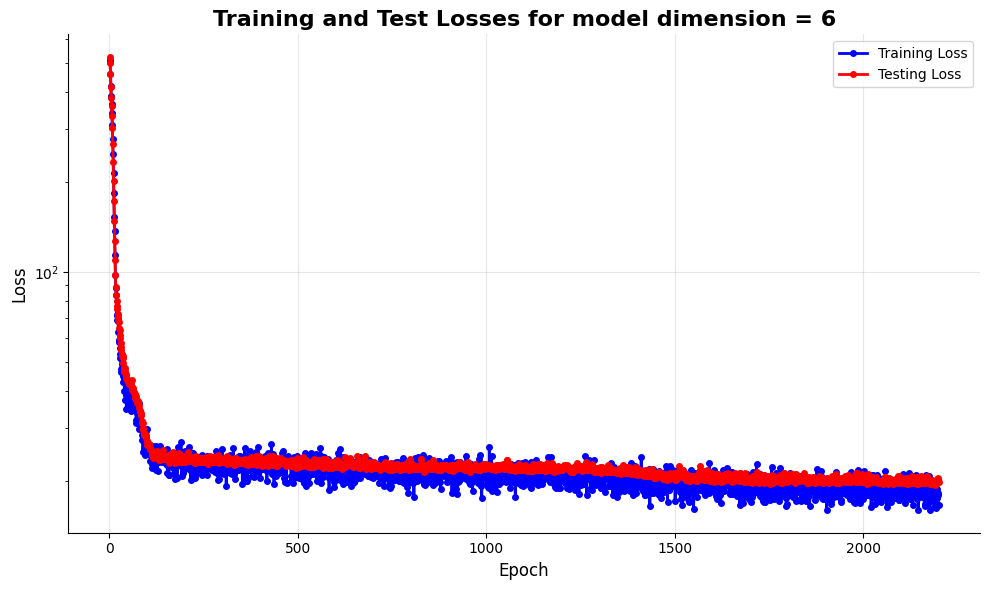

In [20]:
plot_loss(average_losses, test_losses, 6)

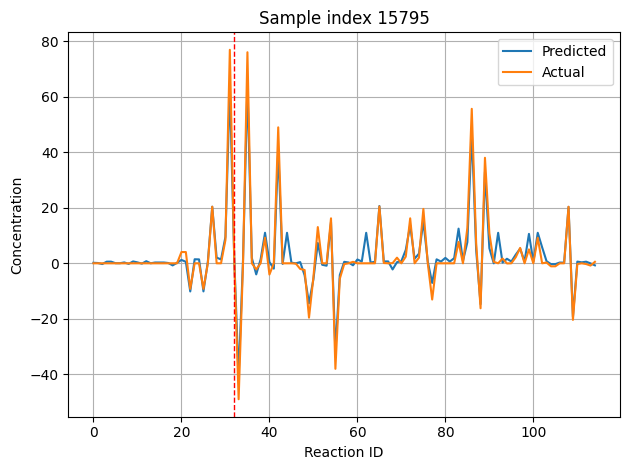

In [21]:
plot_prediction_sample(X_test_, y_test_, trained_model)

Heads = 2
y_pred_tensor.shape: torch.Size([39227, 115, 1])
y_pred_full.shape: (39227, 115) min/max: -70.196335 89.43901
y_true_full.shape: (39227, 115) min/max: -80.44448 109.14731
y_pred_outputs.shape: (39227, 95) min/max: -70.196335 89.43901
y_true_outputs.shape: (39227, 95) min/max: -80.44448 109.14731
Flux column index in outputs: 12
y_true_outputs[:, idx] range: 4.0233743e-05 to 2.649993
y_pred_outputs[:, _idx] range: 0.06466198 to 2.8095932


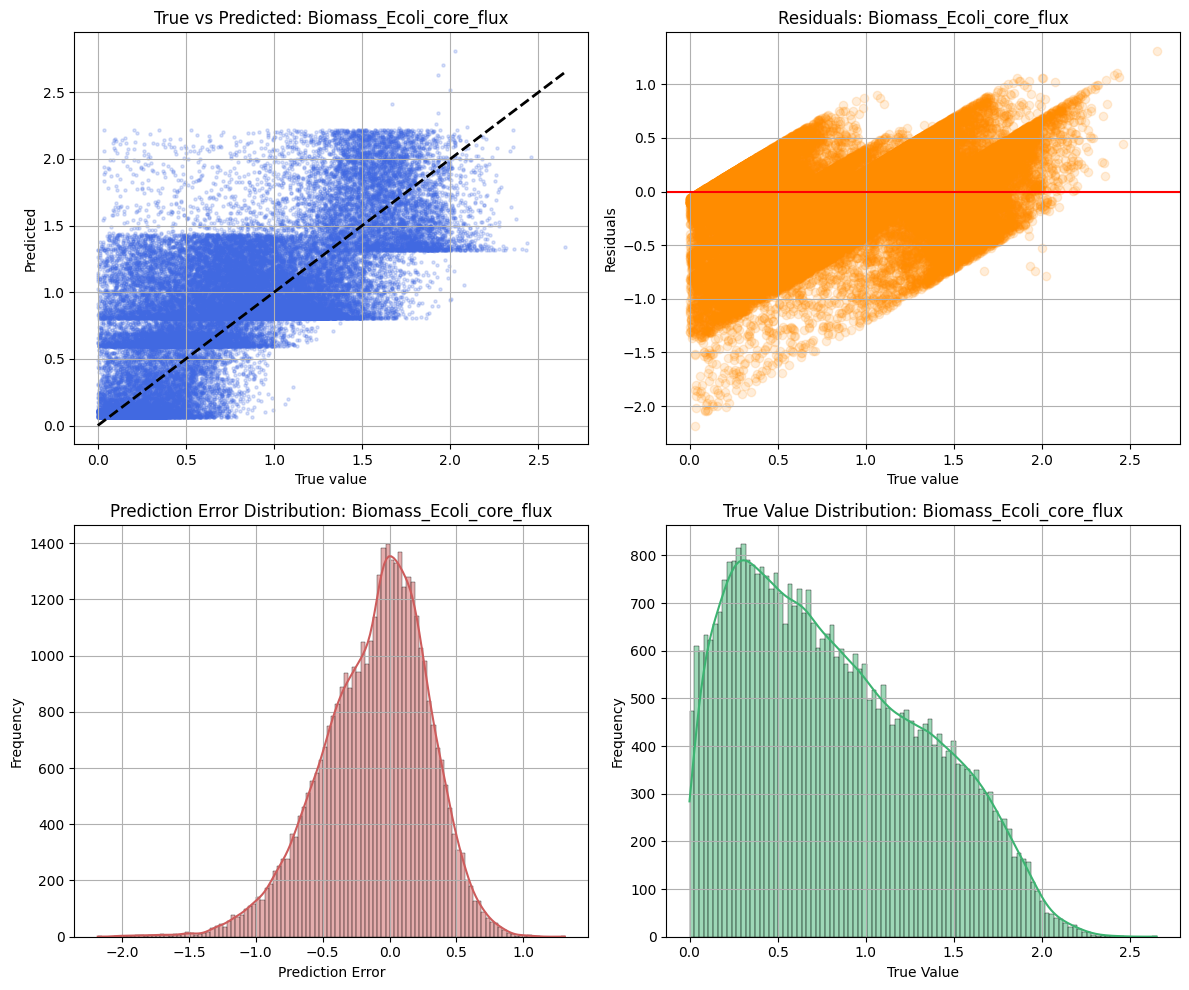

In [22]:
print('Heads = 2')

plot_flux(trained_model, X_test_, y_test, columns, 'Biomass_Ecoli_core_flux', device)

In [23]:
#single head
average_losses615, test_losses615, trained_model615 = train_model(d_model=6, n_heads=1, inner_dim_multiplier=5)

Epoch [440/2200]: Average Training Loss:  34.9514, Test Loss:  36.5049
Epoch [880/2200]: Average Training Loss:  22.7510, Test Loss:  25.9014
Epoch [1320/2200]: Average Training Loss:  20.8842, Test Loss:  24.0880
Epoch [1760/2200]: Average Training Loss:  18.9573, Test Loss:  20.9974
Epoch [2200/2200]: Average Training Loss:  20.4212, Test Loss:  20.6369
Training Completed


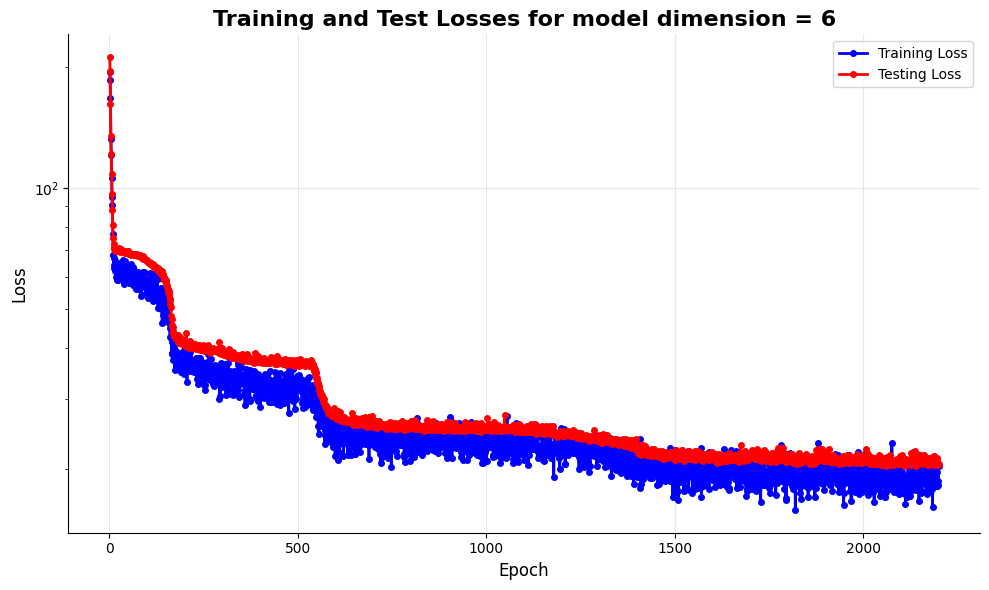

In [24]:
plot_loss(average_losses615, test_losses615, 6)

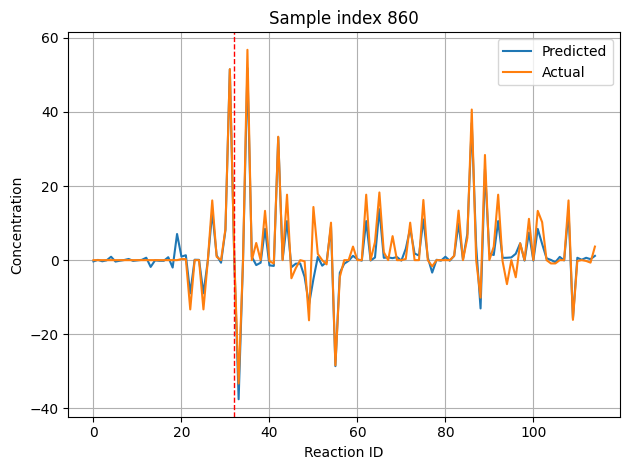

In [25]:
plot_prediction_sample(X_test_, y_test_, trained_model615)

Heads = 1
y_pred_tensor.shape: torch.Size([39227, 115, 1])
y_pred_full.shape: (39227, 115) min/max: -71.48359 80.620346
y_true_full.shape: (39227, 115) min/max: -80.44448 109.14731
y_pred_outputs.shape: (39227, 95) min/max: -71.48359 80.620346
y_true_outputs.shape: (39227, 95) min/max: -80.44448 109.14731
Flux column index in outputs: 12
y_true_outputs[:, idx] range: 4.0233743e-05 to 2.649993
y_pred_outputs[:, _idx] range: 0.32204628 to 3.5785904


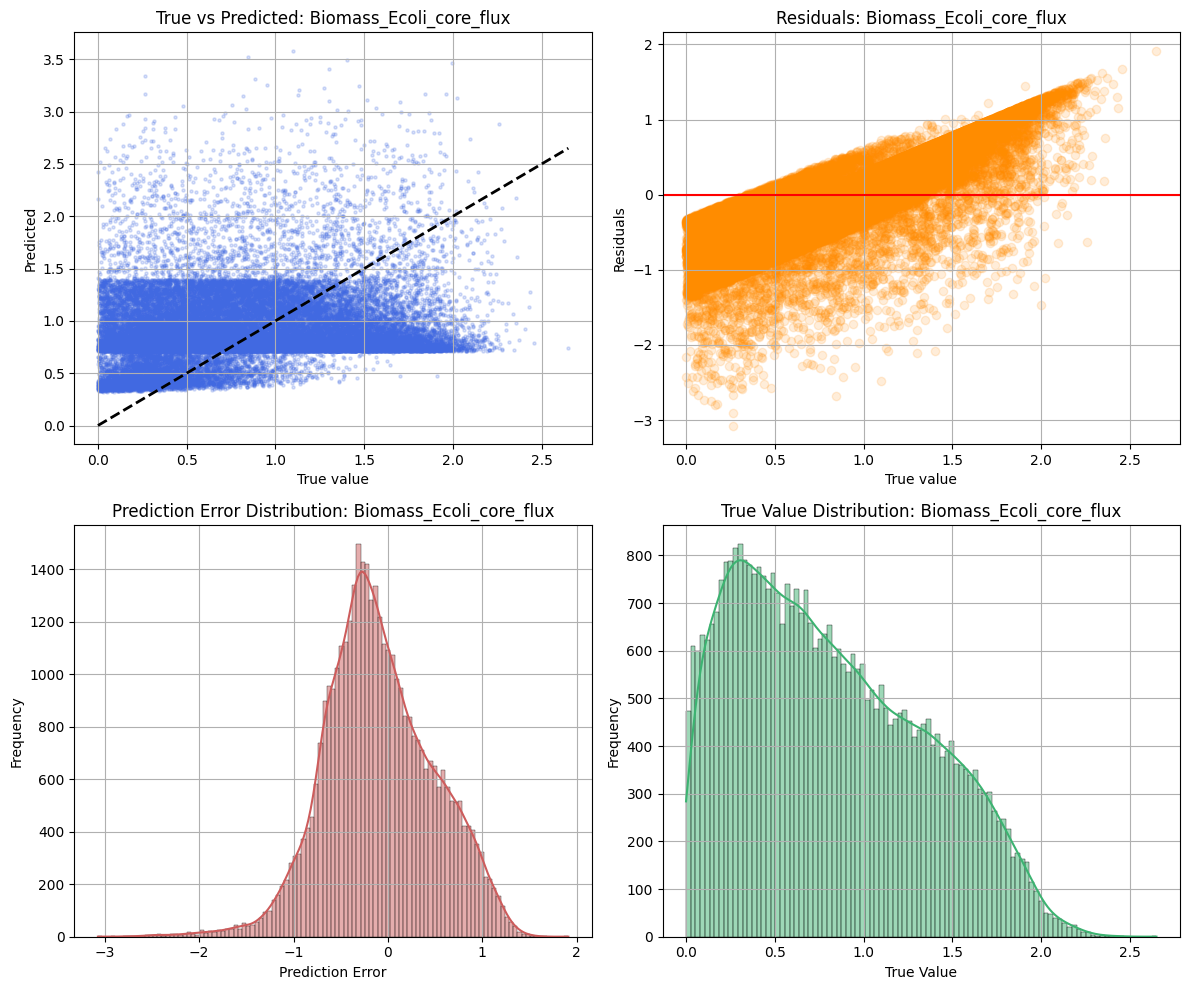

In [26]:
print('Heads = 1')

plot_flux(trained_model615, X_test_, y_test, columns, 'Biomass_Ecoli_core_flux', device)

In [27]:
print(sum( p.numel() for p in trained_model.parameters() if p.requires_grad  ))

14744


In [28]:
print(sum( p.numel() for p in trained_model615.parameters() if p.requires_grad  ))

14732
